<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/nebula_M42.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Nebula M42 (Orion)**

In [5]:
!pip install astropy astroquery -q
from astroquery.ipac.irsa import Irsa
from astropy import units as u
from astropy.coordinates import SkyCoord
from astroquery.simbad import Simbad
from astropy import coordinates
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from astroquery.simbad import Simbad

# Query SIMBAD for information about the Orion Nebula
result_table = Simbad.query_object('M42')

# Print the results
print(result_table)

MAIN_ID     RA        DEC    RA_PREC ... COO_WAVELENGTH     COO_BIBCODE     SCRIPT_NUMBER_ID
         "h:m:s"    "d:m:s"          ...                                                    
------- ---------- --------- ------- ... -------------- ------------------- ----------------
  M  42 05 35 16.8 -05 23 15       5 ...              X 2022A&A...661A..38P                1


In [7]:
# Get skycoordinates of desired object
galaxy = Simbad.query_object('M42')
ra_hms = galaxy['RA'][0]
dec_dms = galaxy['DEC'][0]
print(galaxy)

MAIN_ID     RA        DEC    RA_PREC ... COO_WAVELENGTH     COO_BIBCODE     SCRIPT_NUMBER_ID
         "h:m:s"    "d:m:s"          ...                                                    
------- ---------- --------- ------- ... -------------- ------------------- ----------------
  M  42 05 35 16.8 -05 23 15       5 ...              X 2022A&A...661A..38P                1


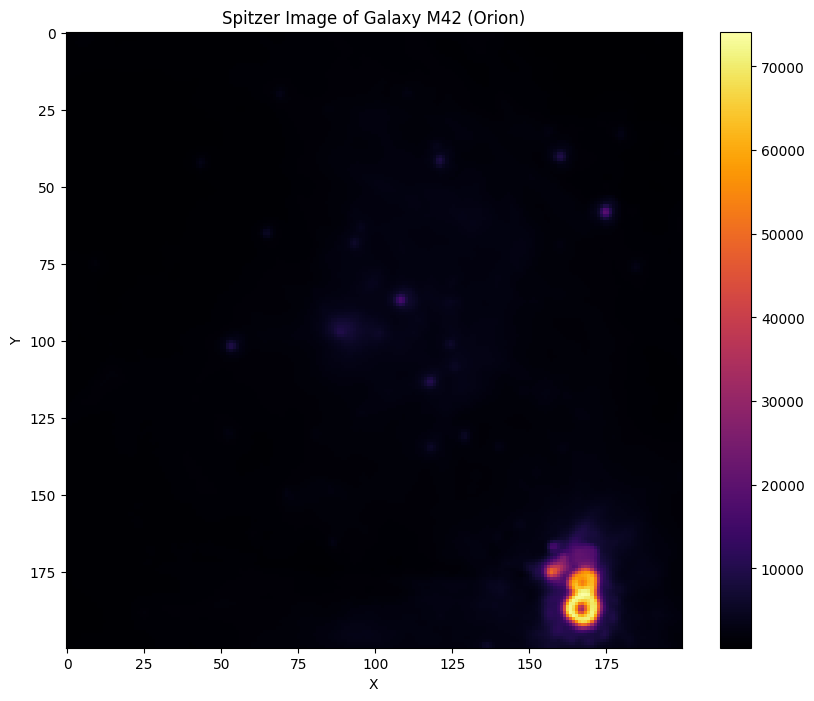

In [12]:
# Simple image access queries from IRSA images from Spitzer telescope
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
spitzer_images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection='spitzer_seip').to_table()

# Open a cutout image for one of the science images
science_image = spitzer_images[spitzer_images['dataproduct_subtype'] == 'science'][30]
with fits.open(science_image['access_url'], use_fsspec=True) as hdul:
    cutout = Cutout2D(hdul[0].section, position=coord, size=2 * u.arcmin, wcs=WCS(hdul[0].header))

plt.figure(figsize=(10, 8))
plt.imshow(cutout.data, cmap='inferno')
plt.colorbar()
plt.title('Spitzer Image of Galaxy M42 (Orion)')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [10]:
# How many science picture are therein spitzer_images?
science_images_count = len(spitzer_images[spitzer_images['dataproduct_subtype'] == 'science'])
print("Number of science images:", science_images_count)

Number of science images: 36
